# Snoozy Meditation Classifier

Binary classifier: **meditation vs. mind-wandering** from the OpenNeuro ds001787 probed EEG sessions.

Hardware target: **nRF54L15 + ADS1299-4 + BNO086**

Design choices:
- 10-second window before each probe onset
- 4 EEG channels selected from the research dataset to match the wearable electrode positions (Fp1, Fp2, AF7, AF8)
- Real-time-computable features: per-channel PSD bands, sub-bands, ratios, Hjorth params, spectral entropy, ZCR + cross-channel coherence and asymmetry
- Leave-One-Participant-Out (LOPO) cross-validation
- Export to ONNX for on-device inference

**Referencing note:** each ADS1299 input is wired as `FpX(+) / AFz(−)` so both channels share a common midline forehead reference. This gives the ADS1299's differential CMRR without collapsing to a single bipolar channel. The cross-channel asymmetry features (log Fp2_α − log Fp1_α, etc.) capture the same lateralization information that a hardware Fp1−Fp2 bipolar would, while keeping both channels available for per-channel features.

## Imports

In [23]:
import json
import warnings
import time
import math
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.signal import welch
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")

## Configuration

In [24]:
DATA_ROOT = Path("dataset/ds001787")
ARTIFACTS_DIR = Path("artifacts")

# --- EEG window ---
CONTEXT_SEC  = 10.0  # pre-probe context: total duration to extract sliding windows from
WINDOW_SEC   = 5.0   # feature window length (each sliding window)
STEP_SEC     = 0.5   # step between consecutive windows -> 11 windows per probe
N_SUBWINDOWS = 5     # split each window into N chunks for intra-window variability features
LOWCUT       = 0.5   # Hz  (bandpass pre-processing)
HIGHCUT      = 40.0  # Hz

# --- Channel selection ---
# BioSemi labelling: A1=Fp1, B2=Fp2, A2=AF7, B3=AF8, B1=Fpz
# ADS1299-4 differential inputs:
#   Ch1: (Fp1-Fp2)  Ch2: (AF7-AF8)  BIAS/REF: Fpz
# We compute (Fp1-Fp2)-Fpz and (AF7-AF8)-Fpz to match the hardware derivation.
PRIMARY_CHANNELS  = ["A1", "B2", "A2", "B3"]  # Fp1, Fp2, AF7, AF8 (needed for bipolars)
REFERENCE_CHANNEL = "B1"                        # Fpz -- subtracted from each bipolar pair
BIPOLAR_LABELS    = ["Fp1-Fp2", "AF7-AF8"]     # logical channel names for feature naming
N_CHANNELS_REQUIRED = 4                         # all 4 primaries must be present

# --- Label mapping ---
Q2_LABEL: Dict[int, str] = {2: "meditation", 4: "mind_wandering", 8: "mind_wandering"}
TARGET_LABELS = ["meditation", "mind_wandering"]

# --- Spectral bands ---
BANDS = {
    "delta":  (0.5,  4.0),
    "theta":  (4.0,  8.0),
    "alpha":  (8.0, 12.0),
    "sigma":  (12.0, 16.0),
    "beta":   (16.0, 30.0),
}
SUB_BANDS = {
    "theta1": (4.0,  6.0),
    "theta2": (6.0,  8.0),
    "alpha1": (8.0, 10.0),
    "alpha2": (10.0, 12.0),
}

USE_EEGNET   = True  # set True to run EEGNet LOPO (requires: braindecode, torch, skorch)
EEGNET_ARCH  = "shallow"  # "shallow" (ShallowFBCSPNet) or "eegnet" (EEGNetv4)
RANDOM_STATE = 42
_n_wins_per_probe = int((CONTEXT_SEC - WINDOW_SEC) / STEP_SEC) + 1
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")
print(f"Sliding windows per probe: {_n_wins_per_probe}  "
      f"({CONTEXT_SEC:.0f}s context, {WINDOW_SEC:.0f}s window, {STEP_SEC}s step)")

DATA_ROOT exists: True
Sliding windows per probe: 11  (10s context, 5s window, 0.5s step)


## Feature Extraction

All features are computable in real-time from a single 5-second window on the nRF54L15 (Cortex-M33).

Feature layout (64 total):
- **Per channel × 2** (F7, F8): 5 band abs powers, 5 rel powers, 4 band ratios, 3 Hjorth, spectral entropy, ZCR, mean/std/rms, 4 sub-band powers, theta peak freq, alpha peak freq → **32 × 2 = 64** per channel
- Subtract cross-channel features from the count: **56 per-channel + 8 cross-channel = 64 total**

In [25]:
def _band_power(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    return float(np.sum(psd[mask])) if np.any(mask) else 0.0


def _peak_freq(psd: np.ndarray, freqs: np.ndarray, lo: float, hi: float) -> float:
    mask = (freqs >= lo) & (freqs < hi)
    if not np.any(mask):
        return (lo + hi) / 2.0
    return float(freqs[mask][np.argmax(psd[mask])])


def _spectral_entropy(psd: np.ndarray) -> float:
    p = psd / (np.sum(psd) + 1e-12)
    return float(-np.sum(p * np.log(p + 1e-12)))


def _spectral_edge_freq(psd: np.ndarray, freqs: np.ndarray, threshold: float = 0.95) -> float:
    cumsum = np.cumsum(psd)
    target = threshold * cumsum[-1]
    idx = int(np.searchsorted(cumsum, target))
    return float(freqs[min(idx, len(freqs) - 1)])


def _permutation_entropy(x: np.ndarray, order: int = 3, delay: int = 1) -> float:
    n = len(x)
    run_len = delay * (order - 1)
    if n <= run_len:
        return 0.0
    counts: dict = {}
    for i in range(n - run_len):
        pattern = tuple(np.argsort(x[i: i + run_len + 1: delay], kind="stable"))
        counts[pattern] = counts.get(pattern, 0) + 1
    total = sum(counts.values())
    probs = np.array(list(counts.values()), dtype=np.float64) / total
    return float(-np.sum(probs * np.log2(probs + 1e-12)))


def _hjorth(x: np.ndarray) -> Tuple[float, float, float]:
    activity = float(np.var(x))
    d1 = np.diff(x)
    mobility = float(np.sqrt(np.var(d1) / (activity + 1e-12)))
    d2 = np.diff(d1)
    mob_d1 = float(np.sqrt(np.var(d2) / (np.var(d1) + 1e-12)))
    complexity = mob_d1 / (mobility + 1e-12)
    return activity, mobility, complexity


def _higuchi_fd(x: np.ndarray, kmax: int = 5) -> float:
    """Higuchi Fractal Dimension -- signal complexity measure (eeglib-inspired)."""
    n = len(x)
    lk = []
    for k in range(1, kmax + 1):
        lm_sum = 0.0
        for m in range(1, k + 1):
            idxs = np.arange(m - 1, n, k)
            if len(idxs) < 2:
                continue
            n_m = len(idxs) - 1
            lm_sum += np.sum(np.abs(np.diff(x[idxs]))) * (n - 1) / (k * n_m)
        lk.append(lm_sum / k)
    k_log  = np.log(np.arange(1, kmax + 1, dtype=np.float64))
    lk_log = np.log(np.array(lk, dtype=np.float64) + 1e-12)
    return float(np.polyfit(k_log, lk_log, 1)[0])


def channel_features(x: np.ndarray, fs: float) -> List[float]:
    """31 features from a single EEG channel."""
    x = x.astype(np.float64)
    nperseg = min(int(fs), len(x))
    freqs, psd = welch(x, fs=fs, nperseg=nperseg)
    total_power = float(np.sum(psd)) + 1e-12

    band_abs = {name: _band_power(psd, freqs, lo, hi) for name, (lo, hi) in BANDS.items()}
    band_rel = {name: v / total_power for name, v in band_abs.items()}

    feats: List[float] = []
    for name in BANDS:
        feats.append(band_abs[name])
    for name in BANDS:
        feats.append(band_rel[name])

    theta, alpha = band_abs["theta"], band_abs["alpha"]
    delta, beta  = band_abs["delta"],  band_abs["beta"]
    feats.append(theta / (alpha + 1e-12))
    feats.append(delta / (beta  + 1e-12))
    feats.append(alpha / (beta  + 1e-12))
    feats.append(theta / (beta  + 1e-12))

    feats.extend(_hjorth(x))
    feats.append(_spectral_entropy(psd))
    feats.append(float(np.mean(np.diff(np.signbit(x)) != 0)))
    feats.append(float(np.mean(x)))
    feats.append(float(np.std(x)))
    feats.append(float(np.sqrt(np.mean(x ** 2))))

    for lo, hi in SUB_BANDS.values():
        feats.append(_band_power(psd, freqs, lo, hi))

    feats.append(_peak_freq(psd, freqs, *BANDS["theta"]))
    feats.append(_peak_freq(psd, freqs, *BANDS["alpha"]))

    feats.append(_spectral_edge_freq(psd, freqs, 0.95))     # SEF95
    feats.append(_permutation_entropy(x, order=3, delay=1)) # PE
    feats.append(_higuchi_fd(x))                            # HFD

    return feats  # 5+5+4+3+1+1+3+4+2+2+1 = 31


def subwindow_features(x: np.ndarray, fs: float) -> List[float]:
    """7 intra-window variability features from a single channel."""
    x = x.astype(np.float64)
    n = len(x)
    chunk_size = n // N_SUBWINDOWS

    bp = np.zeros((N_SUBWINDOWS, len(BANDS)))
    for wi in range(N_SUBWINDOWS):
        chunk = x[wi * chunk_size: (wi + 1) * chunk_size]
        nperseg = min(int(fs), len(chunk))
        freqs, psd = welch(chunk, fs=fs, nperseg=nperseg)
        for bi, (lo, hi) in enumerate(BANDS.values()):
            bp[wi, bi] = _band_power(psd, freqs, lo, hi)

    feats: List[float] = list(bp.std(axis=0))

    t = np.arange(N_SUBWINDOWS, dtype=np.float64)
    feats.append(float(np.polyfit(t, bp[:, 1], 1)[0]))  # theta slope
    feats.append(float(np.polyfit(t, bp[:, 2], 1)[0]))  # alpha slope

    return feats  # 7 features


def cross_channel_features(eeg: np.ndarray, fs: float) -> List[float]:
    """5 features per channel pair: 1 corr + 4 log-asymmetry."""
    n_ch    = eeg.shape[0]
    nperseg = min(int(fs), eeg.shape[1])
    feats: List[float] = []

    psds: List[np.ndarray] = []
    freqs_ref: np.ndarray  = None
    for i in range(n_ch):
        freqs_ref, psd = welch(eeg[i].astype(np.float64), fs=fs, nperseg=nperseg)
        psds.append(psd)

    for i in range(n_ch):
        for j in range(i + 1, n_ch):
            ch_i = eeg[i].astype(np.float64)
            ch_j = eeg[j].astype(np.float64)

            corr = float(np.corrcoef(ch_i, ch_j)[0, 1])
            feats.append(corr if np.isfinite(corr) else 0.0)

            for band_name in ("alpha", "theta", "delta", "beta"):
                lo, hi = BANDS[band_name]
                p_i = _band_power(psds[i], freqs_ref, lo, hi)
                p_j = _band_power(psds[j], freqs_ref, lo, hi)
                feats.append(float(np.log(p_j + 1e-12) - np.log(p_i + 1e-12)))

    return feats  # 5 * n_ch*(n_ch-1)//2 pairs


def extract_features(eeg: np.ndarray, fs: float) -> np.ndarray:
    """Full feature vector for an N-channel EEG epoch (shape: N x samples)."""
    feats: List[float] = []
    for ch in range(eeg.shape[0]):
        feats.extend(channel_features(eeg[ch], fs))
    feats.extend(cross_channel_features(eeg, fs))
    for ch in range(eeg.shape[0]):
        feats.extend(subwindow_features(eeg[ch], fs))
    return np.asarray(feats, dtype=np.float32)


def feature_names(ch_names: Sequence[str]) -> List[str]:
    """Ordered list of feature names matching extract_features output."""
    names: List[str] = []
    for ch in ch_names:
        for band in BANDS:
            names.append(f"{ch}_{band}_abs")
        for band in BANDS:
            names.append(f"{ch}_{band}_rel")
        names += [f"{ch}_theta_alpha", f"{ch}_delta_beta", f"{ch}_alpha_beta", f"{ch}_theta_beta"]
        names += [f"{ch}_hjorth_act", f"{ch}_hjorth_mob", f"{ch}_hjorth_cplx"]
        names.append(f"{ch}_spec_entropy")
        names.append(f"{ch}_zcr")
        names += [f"{ch}_mean", f"{ch}_std", f"{ch}_rms"]
        for sub in SUB_BANDS:
            names.append(f"{ch}_{sub}_abs")
        names.append(f"{ch}_theta_peak_hz")
        names.append(f"{ch}_alpha_peak_hz")
        names.append(f"{ch}_sef95")
        names.append(f"{ch}_perm_entropy")
        names.append(f"{ch}_hfd")

    for i, chi in enumerate(ch_names):
        for j, chj in enumerate(ch_names):
            if j <= i:
                continue
            pair = f"{chi}_{chj}"
            names.append(f"corr_{pair}")
            names += [f"asym_alpha_{pair}", f"asym_theta_{pair}",
                      f"asym_delta_{pair}", f"asym_beta_{pair}"]

    for ch in ch_names:
        for band in BANDS:
            names.append(f"{ch}_{band}_std_sw")
        names.append(f"{ch}_theta_slope_sw")
        names.append(f"{ch}_alpha_slope_sw")

    return names


# Smoke-test -- 2 bipolar channels, 31 per-channel features
_n_ch    = len(BIPOLAR_LABELS)        # 2
_n_pairs = _n_ch * (_n_ch - 1) // 2  # 1
_n_sw    = 7
_expected = _n_ch * 31 + _n_pairs * 5 + _n_ch * _n_sw  # 62 + 5 + 14 = 81
_dummy_eeg   = np.random.randn(_n_ch, int(256 * WINDOW_SEC)).astype(np.float32)
_dummy_feats = extract_features(_dummy_eeg, fs=256.0)
_dummy_names = feature_names(BIPOLAR_LABELS)
print(f"Channels: {_n_ch}  -> {_n_ch*31} per-channel + {_n_pairs*5} cross-channel + {_n_ch*_n_sw} subwindow = {_expected} total")
print(f"Feature vector length : {len(_dummy_feats)}")
print(f"Feature names length  : {len(_dummy_names)}")
assert len(_dummy_feats) == len(_dummy_names) == _expected, \
    f"Feature count mismatch: feats={len(_dummy_feats)}, names={len(_dummy_names)}, expected={_expected}"
print("Feature extraction OK")

Channels: 2  -> 62 per-channel + 5 cross-channel + 14 subwindow = 81 total
Feature vector length : 81
Feature names length  : 81
Feature extraction OK


## Dataset Loading

Selects F7 and F8 from each recording. Falls back to the best-available frontal pair if either channel is missing.

Probe label extraction follows the Q2 convention: stimulus/128 → responses → Q2 is the second response value (2=meditation, 4/8=mind_wandering). Adapted from `med_model.py`.

In [26]:
def _has_required_channels(raw: mne.io.BaseRaw) -> bool:
    available = set(raw.ch_names)
    return all(ch in available for ch in PRIMARY_CHANNELS + [REFERENCE_CHANNEL])


def _extract_probe_label(events_df: pd.DataFrame, probe_idx: int) -> Optional[str]:
    responses: List[int] = []
    for j in range(probe_idx + 1, len(events_df)):
        row = events_df.iloc[j]
        tt = str(row.get("trial_type", "")).strip().lower()
        val = row.get("value")
        if tt == "stimulus" and pd.notna(val) and int(val) == 128:
            break
        if tt == "response" and pd.notna(val) and int(val) in Q2_LABEL:
            responses.append(int(val))
        if len(responses) == 3:
            break
    if len(responses) < 2:
        return None
    return Q2_LABEL.get(responses[1])


def _find_recording_pairs(sub_dir: Path) -> List[Tuple[Path, Path]]:
    pairs: List[Tuple[Path, Path]] = []
    for ses_dir in sorted(sub_dir.glob("ses-*")):
        if not ses_dir.is_dir():
            continue
        eeg_dir = ses_dir / "eeg"
        if not eeg_dir.is_dir():
            continue
        for eeg_path in sorted(eeg_dir.iterdir()):
            if eeg_path.suffix.lower() not in {".edf", ".bdf", ".set", ".fif"}:
                continue
            if "task-meditation" not in eeg_path.name:
                continue
            if f"_eeg{eeg_path.suffix}" not in eeg_path.name:
                continue
            events_path = eeg_path.with_name(
                eeg_path.name.replace(f"_eeg{eeg_path.suffix}", "_events.tsv")
            )
            if events_path.exists():
                pairs.append((eeg_path, events_path))
    return pairs


def _read_raw(eeg_path: Path) -> mne.io.BaseRaw:
    readers = {".edf": mne.io.read_raw_edf, ".bdf": mne.io.read_raw_bdf,
               ".set": mne.io.read_raw_eeglab, ".fif": mne.io.read_raw_fif}
    fn = readers.get(eeg_path.suffix.lower())
    if fn is None:
        raise ValueError(f"Unsupported format: {eeg_path.suffix}")
    return fn(eeg_path, preload=True, verbose="ERROR")


def load_dataset(
    ds_root: Path,
    context_sec: float = CONTEXT_SEC,
    window_sec: float = WINDOW_SEC,
    step_sec: float = STEP_SEC,
    max_subjects: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str], float]:
    """
    Returns X, y, groups, channel_names, sampling_freq.

    For each probe event, sliding windows are extracted over the CONTEXT_SEC
    pre-probe EEG and all window feature vectors are averaged into one probe-level
    sample. One sample per probe -- no label correlation between training examples.
    """
    subject_dirs = sorted(p for p in ds_root.glob("sub-*") if p.is_dir())
    if max_subjects is not None:
        subject_dirs = subject_dirs[:max_subjects]

    canonical_sfreq: Optional[float] = None
    all_X:      List[np.ndarray] = []
    all_y:      List[str]        = []
    all_groups: List[str]        = []

    load_chs = PRIMARY_CHANNELS + [REFERENCE_CHANNEL]

    for sub_dir in subject_dirs:
        pairs = _find_recording_pairs(sub_dir)
        if not pairs:
            print(f"  skip {sub_dir.name}: no meditation EEG pairs")
            continue

        subj_probes = 0
        for rec_idx, (eeg_path, events_path) in enumerate(pairs):
            try:
                raw = _read_raw(eeg_path)
            except Exception as exc:
                print(f"  skip {eeg_path.name}: {exc}")
                continue

            if not _has_required_channels(raw):
                print(f"  skip {eeg_path.name}: required channels {load_chs} not all present")
                continue

            raw.pick(load_chs)
            raw.filter(LOWCUT, HIGHCUT, verbose="ERROR")

            sfreq = float(raw.info["sfreq"])
            if canonical_sfreq is None:
                canonical_sfreq = sfreq
            elif abs(sfreq - canonical_sfreq) > 1e-6:
                raw.resample(canonical_sfreq, npad="auto")
                sfreq = canonical_sfreq

            context_samples = int(round(context_sec * sfreq))
            window_samples  = int(round(window_sec  * sfreq))
            step_samples    = int(round(step_sec    * sfreq))

            idx = {ch: raw.ch_names.index(ch) for ch in load_chs}

            try:
                events_df = pd.read_csv(events_path, sep="\t")
            except Exception as exc:
                print(f"  skip {events_path.name}: {exc}")
                continue

            if not {"onset", "trial_type", "value"}.issubset(events_df.columns):
                print(f"  skip {events_path.name}: missing required columns")
                continue

            for i, row in events_df.iterrows():
                tt  = str(row.get("trial_type", "")).strip().lower()
                val = row.get("value")
                if tt != "stimulus" or pd.isna(val) or int(val) != 128:
                    continue

                label = _extract_probe_label(events_df, i)
                if label not in TARGET_LABELS:
                    continue

                probe_sample  = int(round(float(row["onset"]) * sfreq))
                context_start = probe_sample - context_samples
                if context_start < 0 or probe_sample > raw.n_times:
                    continue

                data_ctx = raw.get_data(start=context_start, stop=probe_sample)
                fpz_ctx  = data_ctx[idx[REFERENCE_CHANNEL]]

                probe_windows: List[np.ndarray] = []
                win_offset = 0
                while win_offset + window_samples <= context_samples:
                    seg = data_ctx[:, win_offset: win_offset + window_samples]
                    fpz = fpz_ctx[win_offset: win_offset + window_samples]
                    segment = np.stack([
                        seg[idx["A1"]] - seg[idx["B2"]] - fpz,
                        seg[idx["A2"]] - seg[idx["B3"]] - fpz,
                    ]).astype(np.float32)
                    probe_windows.append(extract_features(segment, fs=sfreq))
                    win_offset += step_samples

                if not probe_windows:
                    continue

                all_X.append(np.mean(probe_windows, axis=0).astype(np.float32))
                all_y.append(label)
                all_groups.append(sub_dir.name)
                subj_probes += 1

        print(f"  {sub_dir.name}: {subj_probes} probes")

    if not all_X:
        raise ValueError("No usable epochs found -- check DATA_ROOT and channel names")

    X      = np.vstack(all_X).astype(np.float32)
    y      = np.asarray(all_y)
    groups = np.asarray(all_groups)

    print(f"\nLoaded {len(y)} probes from {len(np.unique(groups))} subjects")
    print(f"Class counts: {pd.Series(y).value_counts().to_dict()}")
    print(f"Channels: {BIPOLAR_LABELS}  |  fs: {canonical_sfreq} Hz")
    return X, y, groups, list(BIPOLAR_LABELS), canonical_sfreq


In [27]:
print("Loading dataset...")
X, y, groups, channel_names, fs = load_dataset(DATA_ROOT)

n_features = X.shape[1]
feat_names = feature_names(channel_names)
print(f"Feature matrix: {X.shape}  |  features: {n_features}")
print(f"Subjects: {len(np.unique(groups))}  |  probes: {len(y)}")

Loading dataset...
  sub-001: 53 probes
  sub-002: 54 probes
  sub-003: 28 probes
  sub-004: 13 probes
  sub-005: 36 probes
  sub-006: 46 probes
  sub-007: 40 probes
  sub-008: 24 probes
  sub-009: 32 probes
  sub-010: 48 probes
  sub-011: 52 probes
  sub-012: 28 probes
  sub-013: 19 probes
  sub-014: 12 probes
  sub-015: 25 probes
  sub-016: 23 probes
  sub-017: 30 probes
  sub-018: 55 probes
  sub-019: 29 probes
  sub-020: 25 probes
  sub-021: 33 probes
  sub-022: 22 probes
  sub-023: 35 probes
  sub-024: 42 probes

Loaded 804 probes from 24 subjects
Class counts: {'meditation': 503, 'mind_wandering': 301}
Channels: ['Fp1-Fp2', 'AF7-AF8']  |  fs: 256.0 Hz
Feature matrix: (804, 81)  |  features: 81
Subjects: 24  |  probes: 804


In [28]:
# Z-scoring removed -- SelectKBest + probe-level averaging reduce inter-subject variance.
X_sess = X.copy()
print(f"Feature matrix (no z-score): {X_sess.shape}")

Feature matrix (no z-score): (804, 81)


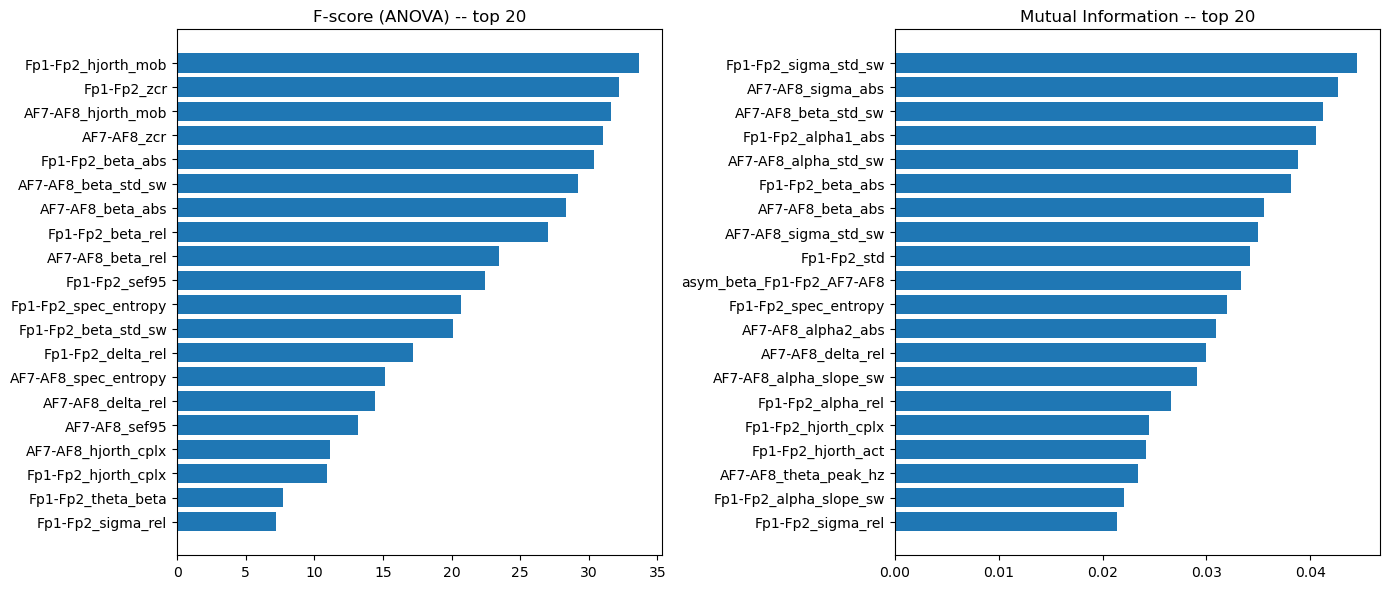

Top 10 by mutual information:
                  feature   f_score  mi_score
     Fp1-Fp2_sigma_std_sw  2.438346  0.044488
        AF7-AF8_sigma_abs  5.329830  0.042714
      AF7-AF8_beta_std_sw 29.235227  0.041184
       Fp1-Fp2_alpha1_abs  0.584140  0.040577
     AF7-AF8_alpha_std_sw  2.796148  0.038815
         Fp1-Fp2_beta_abs 30.382531  0.038161
         AF7-AF8_beta_abs 28.350825  0.035551
     AF7-AF8_sigma_std_sw  2.360071  0.034998
              Fp1-Fp2_std  1.370199  0.034223
asym_beta_Fp1-Fp2_AF7-AF8  0.483736  0.033350


In [29]:
f_scores, _  = f_classif(X_sess, y)
mi_scores     = mutual_info_classif(X_sess, y, random_state=RANDOM_STATE)

ranking_df = pd.DataFrame({
    "feature":  feat_names,
    "f_score":  f_scores,
    "mi_score": mi_scores,
}).sort_values("mi_score", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in [
    (axes[0], "f_score",  "F-score (ANOVA) -- top 20"),
    (axes[1], "mi_score", "Mutual Information -- top 20"),
]:
    top = ranking_df.nlargest(20, col)
    ax.barh(top["feature"][::-1], top[col][::-1])
    ax.set_title(title)
plt.tight_layout()
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(ARTIFACTS_DIR / "feature_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 by mutual information:")
print(ranking_df[["feature", "f_score", "mi_score"]].head(10).to_string(index=False))


## Model & LOPO Cross-Validation

Pipeline: `SimpleImputer → SVC`

The scaler is fit **only on training folds**, so no test-set leakage. LOPO uses all subjects as held-out test subjects in turn.

In [30]:
def make_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("select",  SelectKBest(f_classif, k=50)),
        ("clf",     SVC(kernel="rbf", C=1.0,
                        class_weight={"meditation": 1, "mind_wandering": 2},
                        probability=True, random_state=RANDOM_STATE)),
    ])

print("Pipeline: SimpleImputer -> StandardScaler -> SelectKBest(f_classif, k=50) -> SVC(rbf)")


Pipeline: SimpleImputer -> StandardScaler -> SelectKBest(f_classif, k=50) -> SVC(rbf)


In [31]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

_PARAM_GRID = {
    "select__k": [30, 40, 50],
    "clf__C":    [0.1, 1.0, 10.0],
}


def run_lopo(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
) -> Tuple[List[dict], List[str], List[str], List[float]]:
    logo = LeaveOneGroupOut()
    fold_results: List[dict]  = []
    y_true_all:   List[str]   = []
    y_pred_all:   List[str]   = []
    y_proba_all:  List[float] = []

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups), start=1
    ):
        held_out = str(groups[test_idx][0])

        if len(np.unique(y[test_idx])) < len(TARGET_LABELS):
            print(f"  Fold {fold_idx:2d} | held-out: {held_out} | skipped (single-class test set)")
            continue

        gs = GridSearchCV(
            make_pipeline(),
            _PARAM_GRID,
            cv=inner_cv,
            scoring="balanced_accuracy",
            n_jobs=-1,
            refit=True,
        )
        gs.fit(X[train_idx], y[train_idx])
        model = gs.best_estimator_

        y_pred  = model.predict(X[test_idx])
        med_idx = list(model.classes_).index("meditation")
        y_proba = model.predict_proba(X[test_idx])[:, med_idx]

        fold_results.append({
            "fold":               fold_idx,
            "held_out":           held_out,
            "n_train":            int(len(train_idx)),
            "n_test":             int(len(test_idx)),
            "best_k":             int(gs.best_params_["select__k"]),
            "best_C":             float(gs.best_params_["clf__C"]),
            "accuracy":           float(accuracy_score(y[test_idx], y_pred)),
            "balanced_acc":       float(balanced_accuracy_score(y[test_idx], y_pred)),
            "f1_macro":           float(f1_score(y[test_idx], y_pred, average="macro", zero_division=0)),
            "recall_meditation":  float(recall_score(y[test_idx], y_pred, pos_label="meditation",     zero_division=0)),
            "recall_mw":          float(recall_score(y[test_idx], y_pred, pos_label="mind_wandering", zero_division=0)),
        })
        y_true_all.extend(y[test_idx].tolist())
        y_pred_all.extend(y_pred.tolist())
        y_proba_all.extend(y_proba.tolist())

        print(f"  Fold {fold_idx:2d} | held-out: {held_out} | "
              f"k={gs.best_params_['select__k']} C={gs.best_params_['clf__C']:.1f} | "
              f"bal_acc={fold_results[-1]['balanced_acc']:.3f} | "
              f"F1={fold_results[-1]['f1_macro']:.3f} | "
              f"rec_med={fold_results[-1]['recall_meditation']:.2f} | "
              f"rec_mw={fold_results[-1]['recall_mw']:.2f}")

    return fold_results, y_true_all, y_pred_all, y_proba_all


print("Running LOPO cross-validation (GridSearchCV: k in {30,40,50}, C in {0.1,1,10})...")
fold_results, y_true, y_pred, y_proba = run_lopo(X_sess, y, groups)


Running LOPO cross-validation (GridSearchCV: k in {30,40,50}, C in {0.1,1,10})...
  Fold  1 | held-out: sub-001 | k=50 C=1.0 | bal_acc=0.569 | F1=0.556 | rec_med=0.56 | rec_mw=0.58
  Fold  2 | held-out: sub-002 | k=30 C=10.0 | bal_acc=0.573 | F1=0.480 | rec_med=0.57 | rec_mw=0.57
  Fold  3 | held-out: sub-003 | k=40 C=1.0 | bal_acc=0.286 | F1=0.214 | rec_med=0.14 | rec_mw=0.43
  Fold  4 | held-out: sub-004 | k=30 C=1.0 | bal_acc=0.650 | F1=0.462 | rec_med=0.30 | rec_mw=1.00
  Fold  5 | held-out: sub-005 | k=50 C=1.0 | bal_acc=0.458 | F1=0.234 | rec_med=0.00 | rec_mw=0.92
  Fold  6 | held-out: sub-006 | k=50 C=1.0 | bal_acc=0.569 | F1=0.538 | rec_med=0.64 | rec_mw=0.50
  Fold  7 | held-out: sub-007 | k=40 C=1.0 | bal_acc=0.574 | F1=0.516 | rec_med=0.65 | rec_mw=0.50
  Fold  8 | held-out: sub-008 | k=30 C=10.0 | bal_acc=0.531 | F1=0.521 | rec_med=0.56 | rec_mw=0.50
  Fold  9 | held-out: sub-009 | k=30 C=10.0 | bal_acc=0.694 | F1=0.327 | rec_med=0.39 | rec_mw=1.00
  Fold 10 | held-out: su

## Results

In [32]:
folds_df = pd.DataFrame(fold_results)

print("=" * 55)
print("LOPO Cross-Validation Summary")
print("=" * 55)
print(f"Subjects:          {len(folds_df)}")
print(f"Accuracy:          {folds_df['accuracy'].mean():.3f} ± {folds_df['accuracy'].std():.3f}")
print(f"Balanced accuracy: {folds_df['balanced_acc'].mean():.3f} ± {folds_df['balanced_acc'].std():.3f}")
print(f"F1 macro:          {folds_df['f1_macro'].mean():.3f} ± {folds_df['f1_macro'].std():.3f}")
print()
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, zero_division=0))

folds_df

LOPO Cross-Validation Summary
Subjects:          23
Accuracy:          0.474 ± 0.176
Balanced accuracy: 0.501 ± 0.097
F1 macro:          0.387 ± 0.121

                precision    recall  f1-score   support

    meditation       0.60      0.44      0.51       491
mind_wandering       0.36      0.51      0.42       301

      accuracy                           0.47       792
     macro avg       0.48      0.48      0.47       792
  weighted avg       0.51      0.47      0.48       792



,fold,held_out,n_train,n_test,best_k,best_C,accuracy,balanced_acc,f1_macro,recall_meditation,recall_mw
0,1,sub-001,751,53,50,1.0,0.566038,0.568885,0.555920,0.558824,0.578947
1,2,sub-002,750,54,30,10.0,0.574074,0.572948,0.479682,0.574468,0.571429
2,3,sub-003,776,28,40,1.0,0.214286,0.285714,0.214286,0.142857,0.428571
3,4,sub-004,791,13,30,1.0,0.461538,0.650000,0.461538,0.300000,1.000000
4,5,sub-005,768,36,50,1.0,0.305556,0.458333,0.234043,0.000000,0.916667
5,6,sub-006,758,46,50,1.0,0.608696,0.569444,0.537946,0.638889,0.500000
6,7,sub-007,764,40,40,1.0,0.625000,0.573529,0.515738,0.647059,0.500000
7,8,sub-008,780,24,30,10.0,0.541667,0.531250,0.520871,0.562500,0.500000
8,9,sub-009,772,32,30,10.0,0.406250,0.693548,0.326689,0.387097,1.000000
9,10,sub-010,756,48,50,1.0,0.520833,0.536713,0.510421,0.346154,0.727273


Computing permutation importance (may take ~1 min)...


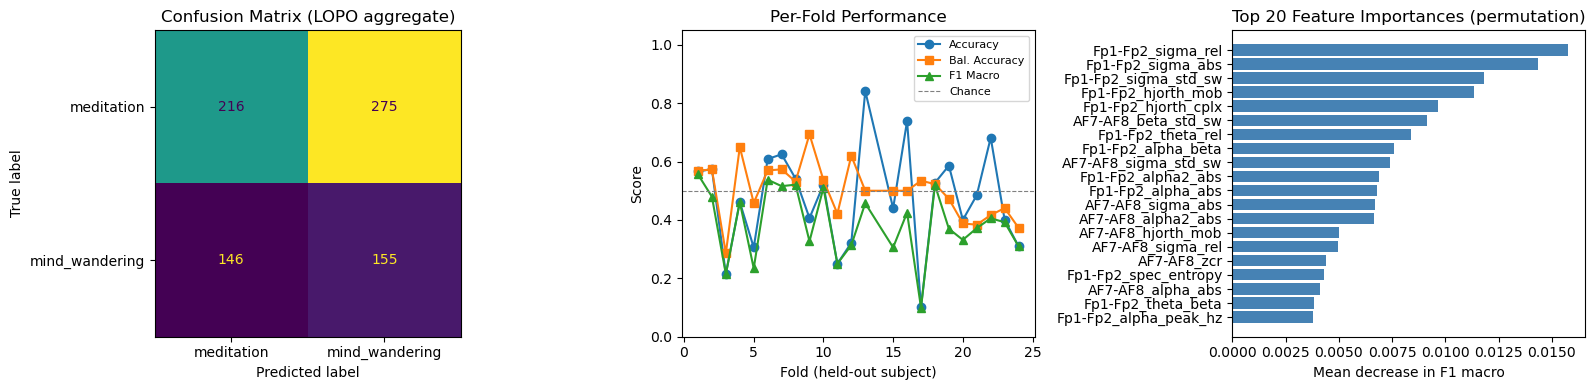

Saved lopo_results.png


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=TARGET_LABELS)
ConfusionMatrixDisplay(cm, display_labels=TARGET_LABELS).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (LOPO aggregate)")

# Per-fold metrics
axes[1].plot(folds_df["fold"], folds_df["accuracy"],     "o-", label="Accuracy")
axes[1].plot(folds_df["fold"], folds_df["balanced_acc"], "s-", label="Bal. Accuracy")
axes[1].plot(folds_df["fold"], folds_df["f1_macro"],     "^-", label="F1 Macro")
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
axes[1].set_xlabel("Fold (held-out subject)")
axes[1].set_ylabel("Score")
axes[1].set_title("Per-Fold Performance")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.05)

# Feature importance via permutation (model-agnostic, works for SVC)
print("Computing permutation importance (may take ~1 min)...")
final_model = make_pipeline()
final_model.fit(X_sess, y)
perm = permutation_importance(
    final_model, X_sess, y,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1_macro",
)
importances = perm.importances_mean
top_n  = 20
top_idx = np.argsort(importances)[::-1][:top_n]
axes[2].barh([feat_names[i] for i in top_idx[::-1]],
             importances[top_idx[::-1]], color="steelblue")
axes[2].set_title(f"Top {top_n} Feature Importances (permutation)")
axes[2].set_xlabel("Mean decrease in F1 macro")

plt.tight_layout()
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(ARTIFACTS_DIR / "lopo_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved lopo_results.png")

## Threshold Tuning

SVC with `probability=True` outputs calibrated probabilities. The default threshold of 0.5 often underpredicts the minority class. Sweeping the threshold using the LOPO-collected probabilities finds the value that maximises F1 macro without re-training.

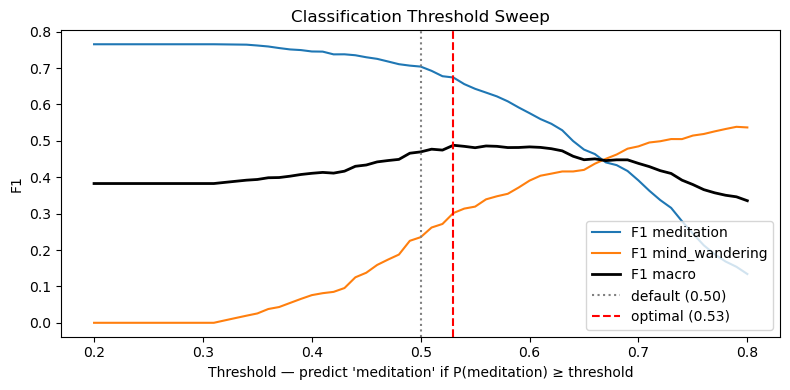

Default  threshold (0.50) → F1 macro: 0.470
Optimal  threshold (0.53) → F1 macro: 0.488  (+0.018)

--- Report at default threshold (0.50) ---
                precision    recall  f1-score   support

    meditation       0.60      0.44      0.51       491
mind_wandering       0.36      0.51      0.42       301

      accuracy                           0.47       792
     macro avg       0.48      0.48      0.47       792
  weighted avg       0.51      0.47      0.48       792

--- Report at optimal threshold (0.53) ---
                precision    recall  f1-score   support

    meditation       0.62      0.74      0.67       491
mind_wandering       0.37      0.25      0.30       301

      accuracy                           0.56       792
     macro avg       0.50      0.50      0.49       792
  weighted avg       0.53      0.56      0.53       792



In [34]:
# Sweep classification threshold using LOPO-collected probabilities.
# Default threshold (0.5) may underpredict meditation — tuning balances per-class F1.
thresholds = np.linspace(0.2, 0.8, 61)
f1_med, f1_mw, f1_mac = [], [], []
y_proba_arr = np.array(y_proba)

for t in thresholds:
    y_pred_t = np.where(y_proba_arr >= t, "meditation", "mind_wandering")
    f1_med.append(f1_score(y_true, y_pred_t, pos_label="meditation",     zero_division=0))
    f1_mw.append( f1_score(y_true, y_pred_t, pos_label="mind_wandering", zero_division=0))
    f1_mac.append(f1_score(y_true, y_pred_t, average="macro",            zero_division=0))

best_t   = thresholds[np.argmax(f1_mac)]
best_f1  = max(f1_mac)
default_f1 = f1_mac[np.argmin(np.abs(thresholds - 0.5))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_med, label="F1 meditation")
ax.plot(thresholds, f1_mw,  label="F1 mind_wandering")
ax.plot(thresholds, f1_mac, label="F1 macro", linewidth=2, color="black")
ax.axvline(0.5,    color="gray", linestyle=":",  label="default (0.50)")
ax.axvline(best_t, color="red",  linestyle="--", label=f"optimal ({best_t:.2f})")
ax.set_xlabel("Threshold — predict 'meditation' if P(meditation) ≥ threshold")
ax.set_ylabel("F1")
ax.set_title("Classification Threshold Sweep")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "threshold_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Default  threshold (0.50) → F1 macro: {default_f1:.3f}")
print(f"Optimal  threshold ({best_t:.2f}) → F1 macro: {best_f1:.3f}  (+{best_f1 - default_f1:.3f})")

# Classification report at optimal threshold
y_pred_tuned = np.where(y_proba_arr >= best_t, "meditation", "mind_wandering")
print(f"\n--- Report at default threshold (0.50) ---")
print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, zero_division=0))
print(f"--- Report at optimal threshold ({best_t:.2f}) ---")
print(classification_report(y_true, y_pred_tuned, target_names=TARGET_LABELS, zero_division=0))

## Real-Time Benchmark

Measure feature extraction and SVM inference time on this machine, then estimate latency on the nRF54L15 (Cortex-M33 @ 128 MHz) using known CMSIS-DSP cycle counts for `arm_rfft_fast_f32`.

In [35]:
# Benchmark feature extraction to show real-time viability on nRF54L15 (Cortex-M33)
n_ch       = len(channel_names)
n_pairs    = n_ch * (n_ch - 1) // 2
sample_seg = np.random.randn(n_ch, int(fs * WINDOW_SEC)).astype(np.float32)

N = 200
t0 = time.perf_counter()
for _ in range(N):
    extract_features(sample_seg, fs)
pc_ms = (time.perf_counter() - t0) / N * 1000

# Time SVM inference separately
N_inf = 500
sample_feat = extract_features(sample_seg, fs).reshape(1, -1)
t0 = time.perf_counter()
for _ in range(N_inf):
    final_model.predict_proba(sample_feat)
infer_ms = (time.perf_counter() - t0) / N_inf * 1000

# nRF54L15 Cortex-M33 @ 128 MHz estimate with CMSIS-DSP
# arm_rfft_fast_f32(256) ≈ 1000 cycles ≈ 8 µs at 128 MHz
# Welch on WINDOW_SEC: ceil(2*WINDOW_SEC) segments per channel
n_segments   = math.ceil(2 * WINDOW_SEC)
fft_us       = n_segments * n_ch * 8    # per-channel Welch FFTs
scalar_us    = 200                       # band sums, Hjorth, ratios, ZCR, log-asymmetry, SEF95 (2 ch)
pe_us        = n_ch * 150               # permutation entropy O(n) per channel
svm_us       = 800                       # O(n_support × n_features)
m33_total_ms = (fft_us + scalar_us + pe_us + svm_us) / 1000

budget_ms = WINDOW_SEC * 1000
headroom  = budget_ms - m33_total_ms

print(f"Channels: {n_ch}  |  pairs: {n_pairs}  |  features: {len(feat_names)}")
print(f"Feature extraction  PC (Python):        {pc_ms:.1f} ms")
print(f"SVM inference       PC (Python):        {infer_ms:.2f} ms")
print()
print(f"M33 estimate (CMSIS-DSP arm_rfft_fast_f32):")
print(f"  FFT  ({n_segments} segs × {n_ch} ch × 8 µs):        {fft_us} µs")
print(f"  Scalar ops (bands, Hjorth, SEF95):      {scalar_us} µs")
print(f"  Permutation entropy ({n_ch} ch):          {pe_us} µs")
print(f"  SVM inference:                          {svm_us} µs")
print(f"  Total:                                  {m33_total_ms:.1f} ms")
print()
print(f"Window budget:  {budget_ms:.0f} ms")
print(f"Headroom:       {headroom:.0f} ms  ({headroom/budget_ms*100:.0f}% of budget remaining)")
print(f"Real-time viable: {'YES' if headroom > 0 else 'NO'}")

Channels: 2  |  pairs: 1  |  features: 81
Feature extraction  PC (Python):        26.5 ms
SVM inference       PC (Python):        1.49 ms

M33 estimate (CMSIS-DSP arm_rfft_fast_f32):
  FFT  (10 segs × 2 ch × 8 µs):        160 µs
  Scalar ops (bands, Hjorth, SEF95):      200 µs
  Permutation entropy (2 ch):          300 µs
  SVM inference:                          800 µs
  Total:                                  1.5 ms

Window budget:  5000 ms
Headroom:       4999 ms  (100% of budget remaining)
Real-time viable: YES


## EEGNet Mode (Optional -- braindecode)

Set `USE_EEGNET = True` in config to run. Install with: `pip install braindecode torch skorch`

In [36]:
def load_raw_dataset(
    ds_root: Path,
    window_sec: float = WINDOW_SEC,
    max_subjects: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:
    """Per-window raw dataset for CNN training.

    Returns one row per sliding window (NOT averaged per probe). Probe-level
    predictions are recovered at inference time by averaging softmax outputs
    over windows that share a probe_id. This gives 11x more training samples
    AND retains time-domain structure that signal-space averaging destroys.
    """
    subject_dirs = sorted(p for p in ds_root.glob("sub-*") if p.is_dir())
    if max_subjects is not None:
        subject_dirs = subject_dirs[:max_subjects]

    canonical_sfreq: Optional[float] = None
    all_X:         List[np.ndarray] = []
    all_y:         List[str]        = []
    all_groups:    List[str]        = []
    all_probe_ids: List[str]        = []
    load_chs = PRIMARY_CHANNELS + [REFERENCE_CHANNEL]

    for sub_dir in subject_dirs:
        pairs = _find_recording_pairs(sub_dir)
        if not pairs:
            continue
        for rec_idx, (eeg_path, events_path) in enumerate(pairs):
            try:
                raw = _read_raw(eeg_path)
            except Exception:
                continue
            if not _has_required_channels(raw):
                continue
            raw.pick(load_chs)
            raw.filter(LOWCUT, HIGHCUT, verbose="ERROR")
            sfreq = float(raw.info["sfreq"])
            if canonical_sfreq is None:
                canonical_sfreq = sfreq
            elif abs(sfreq - canonical_sfreq) > 1e-6:
                raw.resample(canonical_sfreq, npad="auto")
                sfreq = canonical_sfreq

            context_samples = int(round(CONTEXT_SEC * sfreq))
            window_samples  = int(round(window_sec  * sfreq))
            step_samples    = int(round(STEP_SEC    * sfreq))
            idx = {ch: raw.ch_names.index(ch) for ch in load_chs}

            try:
                events_df = pd.read_csv(events_path, sep="\t")
            except Exception:
                continue

            for i, row in events_df.iterrows():
                tt  = str(row.get("trial_type", "")).strip().lower()
                val = row.get("value")
                if tt != "stimulus" or pd.isna(val) or int(val) != 128:
                    continue
                label = _extract_probe_label(events_df, i)
                if label not in TARGET_LABELS:
                    continue
                probe_sample  = int(round(float(row["onset"]) * sfreq))
                context_start = probe_sample - context_samples
                if context_start < 0 or probe_sample > raw.n_times:
                    continue

                data_ctx = raw.get_data(start=context_start, stop=probe_sample)
                fpz_ctx  = data_ctx[idx[REFERENCE_CHANNEL]]
                probe_id = f"{sub_dir.name}_r{rec_idx}_p{i}"

                win_offset = 0
                while win_offset + window_samples <= context_samples:
                    seg = data_ctx[:, win_offset: win_offset + window_samples]
                    fpz = fpz_ctx[win_offset: win_offset + window_samples]
                    segment = np.stack([
                        seg[idx["A1"]] - seg[idx["B2"]] - fpz,
                        seg[idx["A2"]] - seg[idx["B3"]] - fpz,
                    ]).astype(np.float32)
                    # per-channel z-score within this window
                    for ch in range(segment.shape[0]):
                        s = segment[ch].std()
                        if s > 1e-12:
                            segment[ch] = (segment[ch] - segment[ch].mean()) / s
                    all_X.append(segment)
                    all_y.append(label)
                    all_groups.append(sub_dir.name)
                    all_probe_ids.append(probe_id)
                    win_offset += step_samples

    X_raw = np.stack(all_X).astype(np.float32)  # (n_windows, 2, window_samples)
    y_raw = np.asarray(all_y)
    g_raw = np.asarray(all_groups)
    p_raw = np.asarray(all_probe_ids)
    n_probes = len(np.unique(p_raw))
    print(f"Raw dataset: {X_raw.shape}  |  windows={len(X_raw)}  probes={n_probes}  "
          f"classes={pd.Series(y_raw).value_counts().to_dict()}")
    return X_raw, y_raw, g_raw, p_raw, canonical_sfreq


In [37]:
if not USE_EEGNET:
    print("EEGNet mode disabled. Set USE_EEGNET = True in config to run.")
    print("Install: pip install braindecode torch skorch")
else:
    try:
        import torch
        from braindecode.models import ShallowFBCSPNet, EEGNetv4
        from braindecode import EEGClassifier
        from braindecode.augmentation import (
            AugmentedDataLoader, GaussianNoise, SmoothTimeMask,
        )
        from skorch.callbacks import LRScheduler, EarlyStopping
        from skorch.helper import predefined_split
        from skorch.dataset import Dataset as SkorchDataset
        from sklearn.model_selection import train_test_split as tts
        from sklearn.utils.class_weight import compute_class_weight
    except ImportError:
        raise ImportError("Install braindecode + torch: pip install braindecode torch skorch")

    print("Loading raw per-window dataset for CNN...")
    X_raw, y_raw, g_raw, p_raw, fs_raw = load_raw_dataset(DATA_ROOT)

    label_map  = {"meditation": 0, "mind_wandering": 1}
    y_raw_int  = np.array([label_map[lb] for lb in y_raw])
    device_str = "cuda" if torch.cuda.is_available() else "cpu"
    n_times    = X_raw.shape[2]


    def _build_module():
        if EEGNET_ARCH == "eegnet":
            return EEGNetv4(
                n_chans=2, n_outputs=2,
                input_window_seconds=WINDOW_SEC, sfreq=float(fs_raw),
                drop_prob=0.5,
            )
        return ShallowFBCSPNet(
            n_chans=2, n_outputs=2,
            input_window_seconds=WINDOW_SEC, sfreq=float(fs_raw),
            n_filters_time=20, n_filters_spat=20, drop_prob=0.7,
        )


    print(f"Architecture: {EEGNET_ARCH}")
    logo_eeg = LeaveOneGroupOut()
    eeg_fold_results: List[dict] = []
    y_eeg_true: List[int] = []
    y_eeg_pred: List[int] = []

    print("Running CNN LOPO cross-validation (per-window train, probe-aggregated test)...")
    for fold_idx, (train_idx, test_idx) in enumerate(
        logo_eeg.split(X_raw, y_raw_int, g_raw), start=1
    ):
        held_out = str(g_raw[test_idx][0])
        if len(np.unique(y_raw_int[test_idx])) < 2:
            print(f"  Fold {fold_idx:2d} | {held_out} | skipped")
            continue

        # 15% of train windows held back for early-stopping validation
        train_sub, val_sub = tts(
            train_idx, test_size=0.15, stratify=y_raw_int[train_idx],
            random_state=RANDOM_STATE,
        )
        valid_ds = SkorchDataset(X_raw[val_sub], y_raw_int[val_sub])

        cw = compute_class_weight(
            "balanced", classes=np.array([0, 1]), y=y_raw_int[train_sub]
        )
        cw_tensor = torch.FloatTensor(cw).to(device_str)

        transforms = [
            GaussianNoise(probability=0.5, std=0.1, random_state=RANDOM_STATE),
            SmoothTimeMask(probability=0.5, mask_len_samples=int(0.25 * n_times),
                           random_state=RANDOM_STATE),
        ]

        clf = EEGClassifier(
            module=_build_module(),
            criterion=torch.nn.CrossEntropyLoss,
            criterion__weight=cw_tensor,
            optimizer=torch.optim.Adam,
            optimizer__lr=1e-3,
            optimizer__weight_decay=1e-4,
            batch_size=64,
            max_epochs=80,
            iterator_train=AugmentedDataLoader,
            iterator_train__transforms=transforms,
            train_split=predefined_split(valid_ds),
            callbacks=[
                ("lr_sched",   LRScheduler("CosineAnnealingLR", T_max=80)),
                ("early_stop", EarlyStopping(patience=15, monitor="valid_loss")),
            ],
            device=device_str,
            verbose=0,
        )
        clf.fit(X_raw[train_sub], y_raw_int[train_sub])

        # per-window softmax -> aggregate per probe -> argmax
        proba_win = clf.predict_proba(X_raw[test_idx])  # (n_test_windows, 2)
        test_probe_ids = p_raw[test_idx]
        probe_to_proba: Dict[str, list] = {}
        probe_to_label: Dict[str, int]  = {}
        for j, pid in enumerate(test_probe_ids):
            probe_to_proba.setdefault(pid, []).append(proba_win[j])
            probe_to_label[pid] = int(y_raw_int[test_idx][j])
        probe_ids_sorted = sorted(probe_to_proba.keys())
        probe_pred = np.array([
            int(np.argmax(np.mean(probe_to_proba[pid], axis=0)))
            for pid in probe_ids_sorted
        ])
        probe_true = np.array([probe_to_label[pid] for pid in probe_ids_sorted])

        r = {
            "fold":         fold_idx,
            "held_out":     held_out,
            "n_probes":     int(len(probe_true)),
            "accuracy":     float(accuracy_score(probe_true, probe_pred)),
            "balanced_acc": float(balanced_accuracy_score(probe_true, probe_pred)),
            "f1_macro":     float(f1_score(probe_true, probe_pred, average="macro", zero_division=0)),
            "recall_med":   float(recall_score(probe_true, probe_pred, pos_label=0, zero_division=0)),
            "recall_mw":    float(recall_score(probe_true, probe_pred, pos_label=1, zero_division=0)),
            "n_epochs":     int(len(clf.history)),
        }
        eeg_fold_results.append(r)
        y_eeg_true.extend(probe_true.tolist())
        y_eeg_pred.extend(probe_pred.tolist())
        print(f"  Fold {fold_idx:2d} | {held_out} | probes={r['n_probes']:3d} | "
              f"bal_acc={r['balanced_acc']:.3f} | F1={r['f1_macro']:.3f} | "
              f"rec_med={r['recall_med']:.2f} | rec_mw={r['recall_mw']:.2f} | "
              f"epochs={r['n_epochs']}")

    eeg_df = pd.DataFrame(eeg_fold_results)
    print(f"\n{EEGNET_ARCH} LOPO -- Macro F1: {eeg_df['f1_macro'].mean():.3f}  "
          f"Bal Acc: {eeg_df['balanced_acc'].mean():.3f}  "
          f"MW Recall: {eeg_df['recall_mw'].mean():.3f}  "
          f"Avg epochs: {eeg_df['n_epochs'].mean():.1f}")
    print(classification_report(
        y_eeg_true, y_eeg_pred,
        labels=[0, 1], target_names=["meditation", "mind_wandering"], zero_division=0,
    ))


Loading raw per-window dataset for CNN...
Raw dataset: (8844, 2, 1280)  |  windows=8844  probes=804  classes={'meditation': 5533, 'mind_wandering': 3311}
Architecture: shallow
Running CNN LOPO cross-validation (per-window train, probe-aggregated test)...
  Fold  1 | sub-001 | probes= 53 | bal_acc=0.512 | F1=0.424 | rec_med=0.24 | rec_mw=0.79 | epochs=28
  Fold  2 | sub-002 | probes= 54 | bal_acc=0.515 | F1=0.498 | rec_med=0.74 | rec_mw=0.29 | epochs=65
  Fold  3 | sub-003 | probes= 28 | bal_acc=0.452 | F1=0.225 | rec_med=0.05 | rec_mw=0.86 | epochs=41
  Fold  4 | sub-004 | probes= 13 | bal_acc=0.417 | F1=0.405 | rec_med=0.50 | rec_mw=0.33 | epochs=25
  Fold  5 | sub-005 | probes= 36 | bal_acc=0.521 | F1=0.295 | rec_med=0.04 | rec_mw=1.00 | epochs=24
  Fold  6 | sub-006 | probes= 46 | bal_acc=0.522 | F1=0.507 | rec_med=0.94 | rec_mw=0.10 | epochs=80
  Fold  7 | sub-007 | probes= 40 | bal_acc=0.500 | F1=0.459 | rec_med=1.00 | rec_mw=0.00 | epochs=23
  Fold  8 | sub-008 | probes= 24 | bal

In [38]:
if not USE_EEGNET:
    print("EEGNet ONNX export skipped (USE_EEGNET = False).")
else:
    import braindecode

    print(f"Training final {EEGNET_ARCH} on all data for ONNX export...")
    n_epochs_final = max(20, int(round(eeg_df["n_epochs"].mean())))

    cw_all        = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_raw_int)
    cw_tensor_all = torch.FloatTensor(cw_all)  # CPU for portable export

    if EEGNET_ARCH == "eegnet":
        net_final_eeg = EEGNetv4(
            n_chans=2, n_outputs=2,
            input_window_seconds=WINDOW_SEC, sfreq=float(fs_raw),
            drop_prob=0.5,
        )
    else:
        net_final_eeg = ShallowFBCSPNet(
            n_chans=2, n_outputs=2,
            input_window_seconds=WINDOW_SEC, sfreq=float(fs_raw),
            n_filters_time=20, n_filters_spat=20, drop_prob=0.7,
        )

    transforms_final = [
        GaussianNoise(probability=0.5, std=0.1, random_state=RANDOM_STATE),
        SmoothTimeMask(probability=0.5,
                       mask_len_samples=int(0.25 * X_raw.shape[2]),
                       random_state=RANDOM_STATE),
    ]
    clf_final_eeg = EEGClassifier(
        module=net_final_eeg,
        criterion=torch.nn.CrossEntropyLoss,
        criterion__weight=cw_tensor_all,
        optimizer=torch.optim.Adam,
        optimizer__lr=1e-3,
        optimizer__weight_decay=1e-4,
        batch_size=64,
        max_epochs=n_epochs_final,
        iterator_train=AugmentedDataLoader,
        iterator_train__transforms=transforms_final,
        train_split=None,
        device="cpu",
        verbose=0,
    )
    clf_final_eeg.fit(X_raw, y_raw_int)
    print(f"  Trained {n_epochs_final} epochs on {len(X_raw)} windows")

    # --- ONNX export ---
    n_times  = int(round(WINDOW_SEC * fs_raw))
    module_e = clf_final_eeg.module_.eval().cpu()
    dummy    = torch.zeros(1, 2, n_times)
    eegnet_onnx_path = ARTIFACTS_DIR / "meditation_model_eegnet.onnx"
    torch.onnx.export(
        module_e, dummy, str(eegnet_onnx_path),
        input_names=["eeg"],
        output_names=["logits"],
        opset_version=17,
        dynamo=False,
        export_params=True,
        do_constant_folding=True,
    )
    print(f"ONNX model saved: {eegnet_onnx_path}")

    # --- metadata ---
    eegnet_schema = {
        "input_name":  "eeg",
        "output_name": "logits",
        "dtype":       "float32",
        "input_shape": [1, 2, n_times],
        "window_sec":  WINDOW_SEC,
        "sampling_rate_hz": float(fs_raw),
        "n_channels":  2,
        "channel_derivations": [
            "(A1 - B2) - Fpz  [Fp1 - Fp2 - Fpz]",
            "(A2 - B3) - Fpz  [AF7 - AF8 - Fpz]",
        ],
        "normalization": "z-score per channel before inference: x = (x - mean(x)) / std(x)",
        "label_map": {"0": "meditation", "1": "mind_wandering"},
        "architecture": EEGNET_ARCH,
        "braindecode_version": braindecode.__version__,
        "probe_aggregation": (
            f"At inference, run the model on each of the 11 sliding windows from a probe's "
            f"{CONTEXT_SEC}s context (step={STEP_SEC}s), apply softmax to the logits, average "
            f"the probabilities, then argmax for the probe-level prediction."
        ),
        "lopo_cv": {
            "mean_balanced_acc": float(eeg_df["balanced_acc"].mean()),
            "mean_f1_macro":     float(eeg_df["f1_macro"].mean()),
            "mean_recall_med":   float(eeg_df["recall_med"].mean()),
            "mean_recall_mw":    float(eeg_df["recall_mw"].mean()),
            "mean_epochs":       float(eeg_df["n_epochs"].mean()),
            "n_folds":           int(len(eeg_df)),
        },
        "inference_steps": [
            "1. Bipolar derivation: ch0 = (Fp1-Fp2)-Fpz,  ch1 = (AF7-AF8)-Fpz",
            "2. Bandpass filter 0.5-40 Hz on the 10s context buffer",
            "3. Slide 5s windows across the context with step=0.5s -> 11 windows",
            "4. Z-score each channel within each window: x = (x - mean(x)) / std(x)",
            "5. For each window: float32 (1, 2, n_times) -> ONNX -> softmax(logits)",
            "6. Average the 11 softmax outputs; argmax = probe-level label",
        ],
    }
    eegnet_schema_path = ARTIFACTS_DIR / "feature_schema_eegnet.json"
    eegnet_schema_path.write_text(json.dumps(eegnet_schema, indent=2), encoding="utf-8")
    print(f"Schema saved: {eegnet_schema_path}")


Training final shallow on all data for ONNX export...
  Trained 52 epochs on 8844 windows


C:\Users\aidan\AppData\Local\Temp\ipykernel_25220\145357111.py:54: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
c:\Users\aidan\anaconda3\Lib\site-packages\braindecode\modules\layers.py:180: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[-1] == 1:


ONNX model saved: artifacts\meditation_model_eegnet.onnx
Schema saved: artifacts\feature_schema_eegnet.json


In [39]:
if not USE_EEGNET:
    print("NNAPI check + ORT conversion skipped (USE_EEGNET = False).")
else:
    import subprocess
    import sys

    onnx_path = ARTIFACTS_DIR / "meditation_model_eegnet.onnx"

    # ---- NNAPI / CoreML op-coverage report ----
    print("=" * 60)
    print("Mobile usability check (NNAPI / CoreML op coverage)")
    print("=" * 60)
    res = subprocess.run(
        [sys.executable, "-m", "onnxruntime.tools.check_onnx_model_mobile_usability",
         str(onnx_path), "--log_level", "info"],
        capture_output=True, text=True,
    )
    print(res.stdout)
    if res.stderr:
        print("[stderr]", res.stderr)

    # ---- Convert to .ort (mobile-optimized format) ----
    print("=" * 60)
    print("Converting ONNX -> ORT format")
    print("=" * 60)
    res = subprocess.run(
        [sys.executable, "-m", "onnxruntime.tools.convert_onnx_models_to_ort",
         str(onnx_path),
         "--optimization_style", "Fixed",
         "--target_platform", "arm"],
        capture_output=True, text=True,
    )
    print(res.stdout)
    if res.stderr:
        print("[stderr]", res.stderr)

    ort_path = onnx_path.with_suffix(".ort")
    if ort_path.exists():
        onnx_kb = onnx_path.stat().st_size / 1024
        ort_kb  = ort_path.stat().st_size  / 1024
        print(f"\nORT model saved: {ort_path}")
        print(f"  ONNX size: {onnx_kb:7.1f} KB")
        print(f"  ORT  size: {ort_kb:7.1f} KB  ({ort_kb/onnx_kb*100:.0f}% of ONNX)")
    else:
        print("WARNING: .ort file not produced -- check stderr above.")


Mobile usability check (NNAPI / CoreML op coverage)

[stderr] INFO:  Checking artifacts\meditation_model_eegnet.onnx for usability with ORT Mobile.
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\aidan\anaconda3\Lib\site-packages\onnxruntime\tools\check_onnx_model_mobile_usability.py", line 47, in <module>
    check_usability()
    ~~~~~~~~~~~~~~~^^
  File "c:\Users\aidan\anaconda3\Lib\site-packages\onnxruntime\tools\check_onnx_model_mobile_usability.py", line 34, in check_usability
    try_eps = usability_checker.analyze_model(args.model_path, skip_optimize=False, logger=logger)
  File "c:\Users\aidan\anaconda3\Lib\site-packages\onnxruntime\tools\mobile_helpers\usability_checker.py", line 694, in analyze_model
    optimize_model(model_path, tmp_path, use_external_initializers=True)
    ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\aidan\a

## Firmware-Viable Feature Set

Drop the 3 coherence features (`coh_theta`, `coh_alpha`, `coh_beta`): they require cross-spectrum computation (`arm_cmplx_mult_cmplx_f32` + magnitude-squared per bin), which is non-trivial firmware code. Lateralization is already captured by the log-asymmetry features (`asym_*`), which are just `log(P_Fp2) − log(P_Fp1)` computed from band powers already in hand.

All remaining 61 features use only `arm_rfft_fast_f32` + scalar arithmetic (`CONFIG_CMSIS_DSP=y`).

In [40]:
# Full model IS the firmware-viable model: coherence was removed from feature extraction.
# These aliases let downstream cells (ONNX export, TypeScript vectors) remain unchanged.
fw_feat_names = feat_names
fw_mask       = np.ones(len(feat_names), dtype=bool)
X_fw          = X_sess
fw_final      = final_model

print(f"Firmware features: {len(fw_feat_names)} (full model = firmware model -- no coherence in feature set)")

Firmware features: 81 (full model = firmware model -- no coherence in feature set)


In [41]:
# Export firmware ONNX (same as full model since coherence was removed from features)
n_fw_features = len(fw_feat_names)

fw_onnx = convert_sklearn(
    fw_final,
    initial_types=[("input", FloatTensorType([None, n_fw_features]))],
)
fw_onnx_path = ARTIFACTS_DIR / "meditation_model_fw.onnx"
fw_onnx_path.write_bytes(fw_onnx.SerializeToString())

fw_schema = {
    "input_name":       "input",
    "dtype":            "float32",
    "window_sec":       WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names":    list(channel_names),
    "n_features":       n_fw_features,
    "feature_names":    fw_feat_names,
    "classification_threshold": float(best_t),
    "zephyr_note": (
        "All features computable with CONFIG_CMSIS_DSP=y. "
        "Use arm_rfft_fast_f32(256) for Welch PSD segments, then scalar band summation. "
        "Coherence not in feature set -- lateralization captured by log-asymmetry instead."
    ),
    "outputs": TARGET_LABELS,
}
fw_schema_path = ARTIFACTS_DIR / "feature_schema_fw.json"
fw_schema_path.write_text(json.dumps(fw_schema, indent=2), encoding="utf-8")
print(f"Firmware ONNX saved:   {fw_onnx_path}")
print(f"Firmware schema saved: {fw_schema_path}")


Firmware ONNX saved:   artifacts\meditation_model_fw.onnx
Firmware schema saved: artifacts\feature_schema_fw.json


In [42]:
## TypeScript / React Native -- FW ONNX Test Vectors
#
# Exports two feature vectors (one per class) for smoke-testing meditation_model_fw.onnx.
#
# Usage in TypeScript (onnxruntime-react-native):
#   import testData from './fw_onnx_test_data.json';
#   const session = await InferenceSession.create('meditation_model_fw.onnx');
#   const input = new Tensor('float32', testData.examples[0].features, [1, testData.n_features]);
#   const { label } = await session.run({ input });

np.random.seed(RANDOM_STATE)

med_candidates = np.where(y == "meditation")[0]
mw_candidates  = np.where(y == "mind_wandering")[0]


def _pick_correct(candidates, target_label):
    np.random.shuffle(candidates)
    for i in candidates:
        if fw_final.predict(X_fw[i:i+1])[0] == target_label:
            return i
    return candidates[0]


med_idx = _pick_correct(med_candidates, "meditation")
mw_idx  = _pick_correct(mw_candidates,  "mind_wandering")

med_proba = float(fw_final.predict_proba(X_fw[med_idx:med_idx+1])[0,
                  list(fw_final.classes_).index("meditation")])
mw_proba  = float(fw_final.predict_proba(X_fw[mw_idx:mw_idx+1])[0,
                  list(fw_final.classes_).index("meditation")])

examples = [
    {
        "label":        "meditation",
        "subject":      str(groups[med_idx]),
        "p_meditation": round(med_proba, 4),
        "features":     X_fw[med_idx].tolist(),
    },
    {
        "label":        "mind_wandering",
        "subject":      str(groups[mw_idx]),
        "p_meditation": round(mw_proba, 4),
        "features":     X_fw[mw_idx].tolist(),
    },
]

ts_data = {
    "description": (
        "FW ONNX smoke-test data for TypeScript/React Native. "
        "Features are in raw scale (no z-scoring applied). "
        "Pass features directly to meditation_model_fw.onnx as float32 input."
    ),
    "model_file":               "meditation_model_fw.onnx",
    "n_features":               len(fw_feat_names),
    "feature_names":            fw_feat_names,
    "classification_threshold": float(best_t),
    "labels":                   TARGET_LABELS,
    "inference_note": (
        "At runtime: (1) compute bipolar EEG derivations (Fp1-Fp2)-Fpz and (AF7-AF8)-Fpz, "
        "(2) extract features via the firmware feature pipeline over a 5s window, "
        "(3) feed the float32 vector to the ONNX model, "
        "(4) if output_probability >= classification_threshold -> 'meditation' else 'mind_wandering'."
    ),
    "examples": examples,
}

ts_json_path = ARTIFACTS_DIR / "fw_onnx_test_data.json"
ts_json_path.write_text(json.dumps(ts_data, indent=2), encoding="utf-8")
print(f"TypeScript test data saved: {ts_json_path}")

ts_lines = [
    "// Auto-generated by meditation.ipynb -- do not edit by hand.",
    "// Feed testVectors directly to meditation_model_fw.onnx for smoke-testing.",
    "",
    f"export const FW_N_FEATURES = {len(fw_feat_names)};",
    f"export const FW_THRESHOLD  = {best_t:.4f};  // P(meditation) >= threshold -> 'meditation'",
    "export type MeditationLabel = 'meditation' | 'mind_wandering';",
    "",
    "export interface FwTestVector {",
    "  label:        MeditationLabel;",
    "  pMeditation:  number;",
    "  features:     number[];   // raw scale, length = FW_N_FEATURES",
    "}",
    "",
    "export const FW_TEST_VECTORS: FwTestVector[] = [",
]
for ex in examples:
    feat_str = ", ".join(f"{v:.6f}" for v in ex["features"])
    ts_lines += [
        "  {",
        f"    label:       '{ex['label']}',",
        f"    pMeditation:  {ex['p_meditation']},",
        f"    features:    [{feat_str}],",
        "  },",
    ]
ts_lines += ["];", ""]

ts_file_path = ARTIFACTS_DIR / "fw_test_vectors.ts"
ts_file_path.write_text("\n".join(ts_lines), encoding="utf-8")
print(f"TypeScript constants saved: {ts_file_path}")
print()
print(f"Meditation example     -> P(meditation)={med_proba:.3f}  (subject {groups[med_idx]})")
print(f"Mind-wandering example -> P(meditation)={mw_proba:.3f}  (subject {groups[mw_idx]})")


TypeScript test data saved: artifacts\fw_onnx_test_data.json
TypeScript constants saved: artifacts\fw_test_vectors.ts

Meditation example     -> P(meditation)=0.863  (subject sub-002)
Mind-wandering example -> P(meditation)=0.395  (subject sub-024)


## Export — ONNX Model & Feature Schema

In [43]:
# ONNX export
onnx_model = convert_sklearn(
    final_model,
    initial_types=[("input", FloatTensorType([None, n_features]))],
)
onnx_path = ARTIFACTS_DIR / "meditation_model_snoozy.onnx"
onnx_path.write_bytes(onnx_model.SerializeToString())
print(f"ONNX model saved: {onnx_path}")

# Joblib export (for quick Python inference during development)
joblib_path = ARTIFACTS_DIR / "meditation_model_snoozy.joblib"
joblib.dump(final_model, joblib_path)
print(f"Joblib model saved: {joblib_path}")

# Feature schema for the Snoozy firmware / app
schema = {
    "input_name": "input",
    "dtype": "float32",
    "window_sec": WINDOW_SEC,
    "sampling_rate_hz": float(fs),
    "channel_names": list(channel_names),
    "hardware_referencing": (
        "Two bipolar EEG derivations: (Fp1−Fp2)−Fpz and (AF7−AF8)−Fpz. "
        "ADS1299-4 Ch1: A(Fp1) − B(Fp2), Ch2: A(AF7) − B(AF8), BIAS/REF: Fpz. "
        "Subtract the Fpz sample from each bipolar output before feature extraction."
    ),
    "n_features": n_features,
    "feature_names": feat_names,
    "bands_hz": {k: list(v) for k, v in BANDS.items()},
    "sub_bands_hz": {k: list(v) for k, v in SUB_BANDS.items()},
    "bandpass_hz": [LOWCUT, HIGHCUT],
    "classification_threshold": float(best_t),
    "outputs": TARGET_LABELS,
    "lopo_cv": {
        "mean_accuracy":     float(folds_df["accuracy"].mean()),
        "std_accuracy":      float(folds_df["accuracy"].std()),
        "mean_balanced_acc": float(folds_df["balanced_acc"].mean()),
        "mean_f1_macro":     float(folds_df["f1_macro"].mean()),
        "mean_recall_mw":    float(folds_df["recall_mw"].mean()),
        "n_subjects":        int(len(folds_df)),
    },
    "notes": (
        "Binary meditation vs. mind_wandering classifier for Snoozy (nRF54L15 + ADS1299-4). "
        "Input to ONNX is the engineered feature vector, not raw EEG. "
        f"Features extracted from {len(channel_names)}-channel {WINDOW_SEC:.0f}s EEG window. "
        "Trained on OpenNeuro ds001787 with LOPO CV. "
        "Use classification_threshold instead of 0.5 — tuned to maximise F1 macro."
    ),
}

schema_path = ARTIFACTS_DIR / "feature_schema_snoozy.json"
schema_path.write_text(json.dumps(schema, indent=2), encoding="utf-8")
print(f"Feature schema saved: {schema_path}")

ONNX model saved: artifacts\meditation_model_snoozy.onnx
Joblib model saved: artifacts\meditation_model_snoozy.joblib
Feature schema saved: artifacts\feature_schema_snoozy.json


## Sanity Check — ONNX Inference

In [44]:
import onnxruntime as ort

sess = ort.InferenceSession(str(onnx_path))
input_name  = sess.get_inputs()[0].name
output_name = sess.get_outputs()[0].name

# Use session-normalized features — the model was trained on X_sess
sample = X_sess[:1].astype(np.float32)
sklearn_pred = final_model.predict(sample)[0]
onnx_pred    = sess.run([output_name], {input_name: sample})[0][0]

print(f"sklearn prediction : {sklearn_pred}")
print(f"ONNX   prediction  : {onnx_pred}")
assert sklearn_pred == onnx_pred, "Prediction mismatch between sklearn and ONNX!"
print("ONNX sanity check passed.")
print(f"\nONNX input shape expected: [batch, {n_features}]")

sklearn prediction : mind_wandering
ONNX   prediction  : mind_wandering
ONNX sanity check passed.

ONNX input shape expected: [batch, 81]
